## Feature Engineering


### Imports

In [1]:
from feature_engineering import merge_and_engineer_features, load_and_clean_data

In [2]:
# Step 1: Load and Clean Data
df_energy_clean, city_dfs_clean = load_and_clean_data(
    energy_path="data/energy_dataset.csv", 
    weather_path="data/weather_features.csv"
)

# Step 2: Feature Engineering
df_model = merge_and_engineer_features(df_energy_clean, city_dfs_clean)

# Step 3: Verify Results
print("\n--- SAMPLE OUTPUT ---")
cols_to_show = [
    'total load actual', 'day_type', 'is_holiday_madrid', 'is_holiday_barcelona',
    'temp_madrid', 'temp_barcelona', 'temp_madrid_lag_24', 'load_rolling_mean_24h'
]
display(df_model[cols_to_show].head())


--- 1. LOADING AND CLEANING DATA ---
Processing Energy Dataset...
Processing Weather Dataset...
Data loading and cleaning complete.

--- 2. FEATURE ENGINEERING ---
Merging individual city weather datasets...
Creating temporal variables and cyclical encoding...
Incorporating external covariates: National and Regional Holidays...
Generating safe lags for Day-Ahead prediction...
Generating safe rolling window statistics...
Dropping rows with NaNs generated by lags (first 8 days)...
✅ Process completed. Final dimensions: (34873, 103)

--- SAMPLE OUTPUT ---


,total load actual,day_type,is_holiday_madrid,is_holiday_barcelona,temp_madrid,temp_barcelona,temp_madrid_lag_24,load_rolling_mean_24h
time,,,,,,,,
2015-01-08 22:00:00+00:00,26436.0,0,0,0,-3.856,9.6,-5.0910,32105.000000
2015-01-08 23:00:00+00:00,27485.0,0,0,0,-3.856,10.4,-5.0910,31949.583333
2015-01-09 00:00:00+00:00,25750.0,0,0,0,-3.856,10.3,-5.4325,31810.500000
2015-01-09 01:00:00+00:00,24760.0,0,0,0,-3.902,10.0,-5.7740,31679.791667
2015-01-09 02:00:00+00:00,24188.0,0,0,0,-3.902,10.4,-5.7740,31546.375000


Splitting data at cutoff date: 2018-01-01 00:00:00+00:00
  Training set: 26,114 hours (2015-01-08 to 2017-12-31)
  Testing set:  8,759 hours (2018-01-01 to 2018-12-31)

Calculating official TSO baseline metrics...
🎯 OFFICIAL TSO BASELINE (2018):
   MAE:  269.85 MWh
   MAPE: 0.926 %
   RMSE: 389.32 MWh


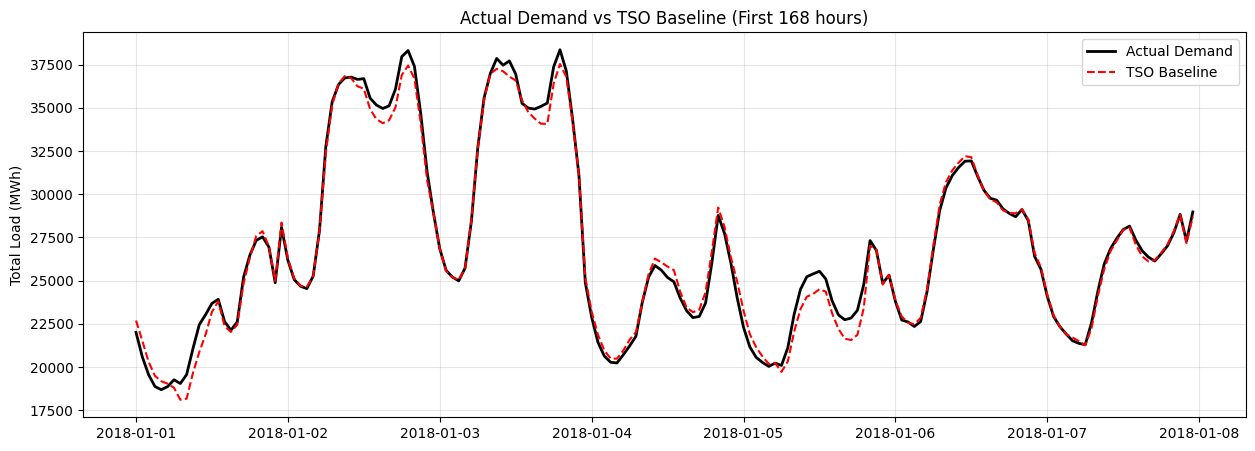

In [3]:
# Import the functions from your newly created .py file
from evaluate import temporal_train_test_split, evaluate_tso_baseline, plot_forecast_vs_actual

# 1. Split the data (assuming df_model is your fully engineered dataframe)
X_train, X_test, y_train, y_test = temporal_train_test_split(
    df=df_model, 
    target_col='total load actual', 
    cutoff_date='2018-01-01 00:00:00+00:00'
)

# 2. Get the baseline metrics to beat
tso_forecast, tso_metrics = evaluate_tso_baseline(
    y_test=y_test, 
    energy_csv_path="data/energy_dataset.csv"
)

# 3. Visualize the first week of 2018
plot_forecast_vs_actual(y_actual=y_test, y_pred=tso_forecast, model_name="TSO Baseline", window_hours=168)

In [ ]:
from Time_Series_Final_Project.modeling_ml import tune_xgboost_with_cv
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np
best_xgb_model = tune_xgboost_with_cv(X_train, y_train)

# Now evaluate this optimized model against the official TSO baseline on the Test set
print("\n--- 5. FINAL EVALUATION ON HOLD-OUT TEST SET (2018) ---")
y_pred_tuned = best_xgb_model.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred_tuned)
final_mape = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
print(f"Tuned XGBoost Test MAE: {final_mae:,.2f} MWh")
print(f"Tuned XGBoost Test MAPE: {final_mape:.3f} %")
print(f"Tuned XGBoost Test RMSE: {final_rmse:,.2f} MWh")

--- 4. HYPERPARAMETER TUNING WITH TIME SERIES CV ---
Starting cross-validation search (this might take a few minutes)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Cross-Validation Complete!
Best Hyperparameters Found:
   - subsample: 0.7
   - n_estimators: 800
   - max_depth: 6
   - learning_rate: 0.1
   - colsample_bytree: 0.8

Expected Validation MAE (based on CV): 1,151.01 MWh

--- 5. FINAL EVALUATION ON HOLD-OUT TEST SET (2018) ---
Tuned XGBoost Test MAE: 1,030.50 MWh


--- 4. TRAINING LIGHTGBM WITH QUANTILE REGRESSION ---
Training Median Model (Alpha = 0.50)...
Training Lower Bound Model (Alpha = 0.10)...
Training Upper Bound Model (Alpha = 0.90)...

📊 LIGHTGBM MEDIAN FORECAST RESULTS (2018):
   MAE:  1,030.69 MWh
   MAPE: 3.575 %
   RMSE: 1,325.27 MWh

--- 5. EVALUATING PREDICTION INTERVALS ---
🎯 INTERVAL METRICS (Target Coverage: ~80%):
   PICP (Coverage): 45.46% of actual values fell inside the interval.
   MPIW (Width):    1,721.74 MWh average width of the uncertainty band.


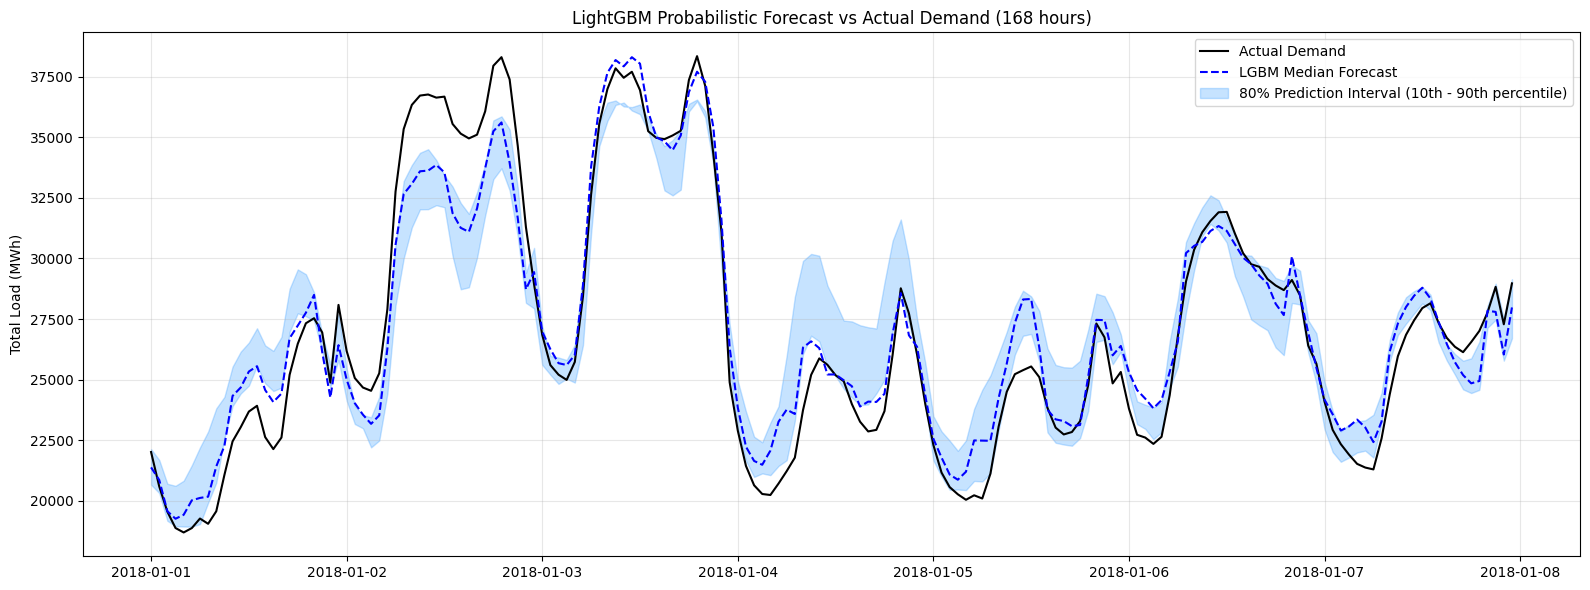

In [ ]:
# 1. Train models and get predictions
from Time_Series_Final_Project.modeling_ml import train_and_evaluate_lgbm_quantiles, evaluate_prediction_intervals, plot_lightgbm_intervals
df_quantiles, best_lgbm = train_and_evaluate_lgbm_quantiles(X_train, y_train, X_test, y_test)

# 2. Calculate interval metrics (PICP and MPIW)
picp, mpiw = evaluate_prediction_intervals(df_quantiles)

# 3. Visualize the first week with the beautiful uncertainty bands
plot_lightgbm_intervals(df_quantiles, window_hours=168, start_idx=0)


--- 5. TRAINING META PROPHET (ADDITIVE MODEL) ---
Formatting data for Prophet (ds, y)...
Initializing model and adding external regressors...
Fitting Prophet model (this may take a minute or two on hourly data)...


17:44:03 - cmdstanpy - INFO - Chain [1] start processing
17:44:33 - cmdstanpy - INFO - Chain [1] done processing


Making predictions on the 2018 Test Set...

📊 PROPHET MODEL RESULTS (TEST SET 2018):
---------------------------------------------
   MAE:  973.07 MWh
   MAPE: 3.360 %
   RMSE: 1,249.56 MWh
   PICP: 89.44% (Target: 80% coverage)


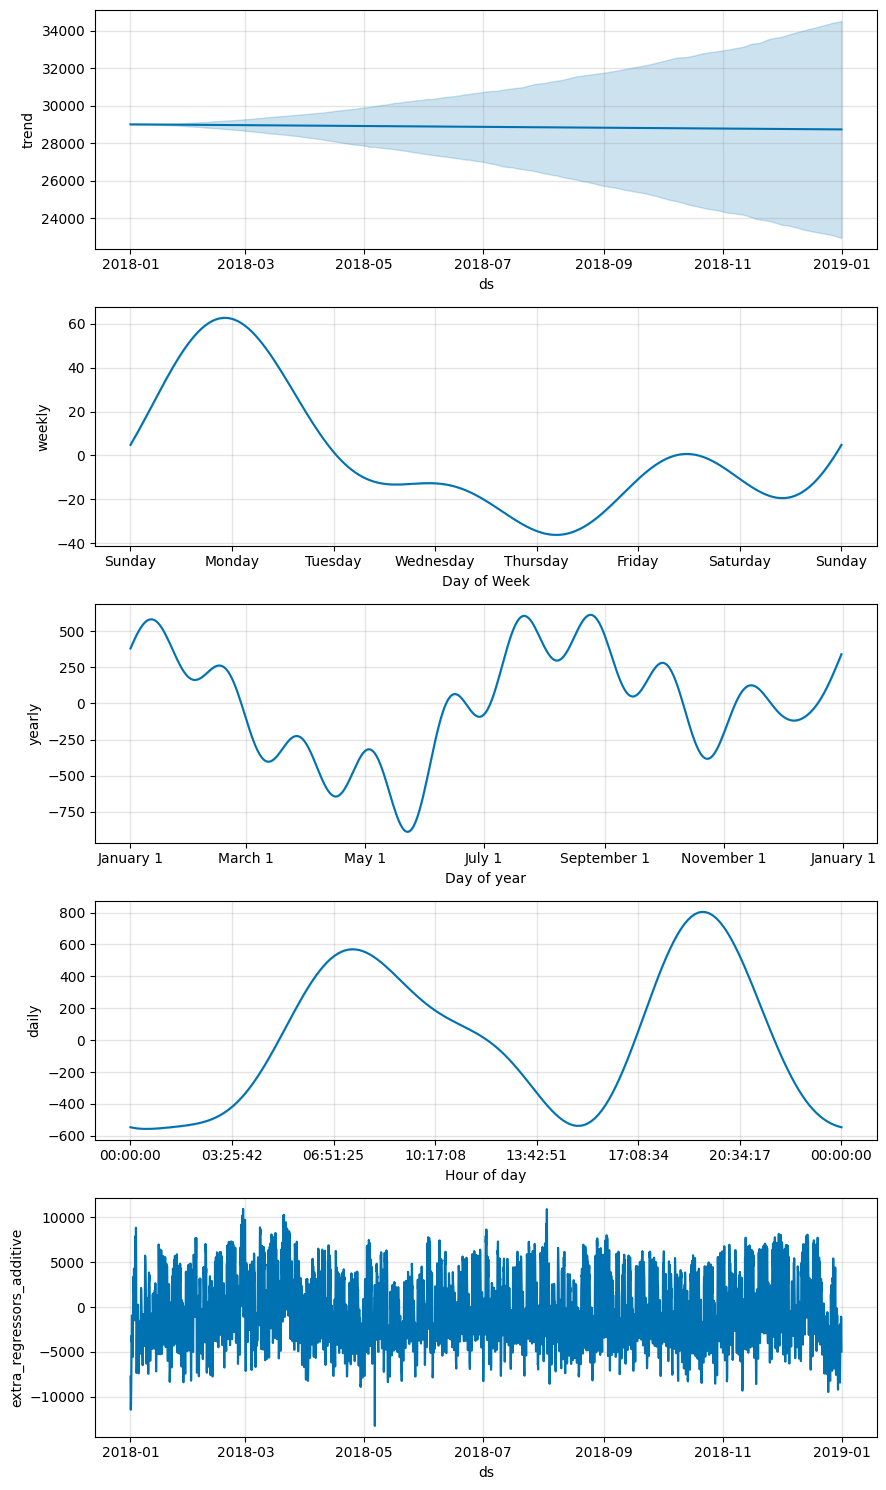

In [ ]:
from Time_Series_Final_Project.modeling_ml import train_and_evaluate_prophet
import matplotlib.pyplot as plt
model_prophet, prophet_forecast = train_and_evaluate_prophet(X_train, y_train, X_test, y_test)

# BONUS: Prophet has amazing built-in plotting for its components
# This plot breaks down the Trend vs Weekly vs Daily vs Regressors effect
# (SAVE THIS IMAGE FOR YOUR REPORT!)
fig_comp = model_prophet.plot_components(prophet_forecast)
plt.show()

In [ ]:
from Time_Series_Final_Project.modeling_ml import train_alternative_models
pred_cat, pred_mlp, pred_rf = train_alternative_models(X_train, y_train, X_test, y_test)

--- 4. TRAINING ALTERNATIVE MODELS ---
Scaling features...

Training Model A: CatBoost...
Training Model B: Neural Network (MLPRegressor)...
Training Model C: Random Forest...

📊 ALTERNATIVE MODELS COMPARISON (TEST SET 2018):
Metric     | TSO (Goal)   | CatBoost     | Neural Net   | RandomForest
---------------------------------------------------------------------------
MAE (MWh)  | 269.85       | 980.24       | 1197.22      | 1233.32     
MAPE (%)   | 0.926        | 3.420        | 4.204        | 4.236       
RMSE (MWh) | 389.32       | 1245.11      | 1505.40      | 1646.08     


In [4]:
from modeling_dl import prepare_darts_from_split, train_and_evaluate_deep_learning_fleet
darts_dataset = prepare_darts_from_split(X_train, y_train, X_test, y_test)

# Step 2: Train all models and evaluate. 
# You can change epochs=5 to epochs=15 when you want to run the final heavy test.
predictions, leaderboard = train_and_evaluate_deep_learning_fleet(
    darts_dataset, 
    lookback_hours=168, 
    horizon=24, 
    max_epochs=60
)

Importing plotly failed. Interactive plots will not work.
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


--- 1. PREPARING DARTS DATA FROM EXISTING TRAIN/TEST SPLIT ---
Identified Future Covariates: 12 columns
Identified Past Covariates: 90 columns
Scaling TimeSeries data...
✅ Darts Data Preparation Complete.

🚀 LAUNCHING DEEP LEARNING FLEET (6 MODELS)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_cr


--- 🧠 TRAINING LSTM ---


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


💾 Model saved to: saved_models/TFT_model.pt
Predicting 2018 with TFT (Historical Forecasts simulating Day-Ahead)...
✅ TFT Completed in 13 epochs. MAE: 1,687.20 MWh
📈 Loss curves saved to: saved_models/TFT_loss_curves.csv

🏆 DEEP LEARNING LEADERBOARD (TEST SET 2018) 🏆
Model        | MAE (MWh)    | MAPE (%)   | RMSE (MWh)  
-------------------------------------------------------
TSO (Goal)   | 269.85       | 0.926      | 389.32      
TFT          | 1687.20      | 5.852      | 2408.01     
GRU          | 2068.19      | 7.346      | 2834.72     
LSTM         | 2132.60      | 6.945      | 2914.46     
N-HiTS       | 2227.95      | 7.501      | 2916.40     
N-BEATS      | 2326.99      | 7.867      | 3108.88     
TCN          | 2600.51      | 8.751      | 3483.15     

 All configurations saved to: saved_models/fleet_configs.json


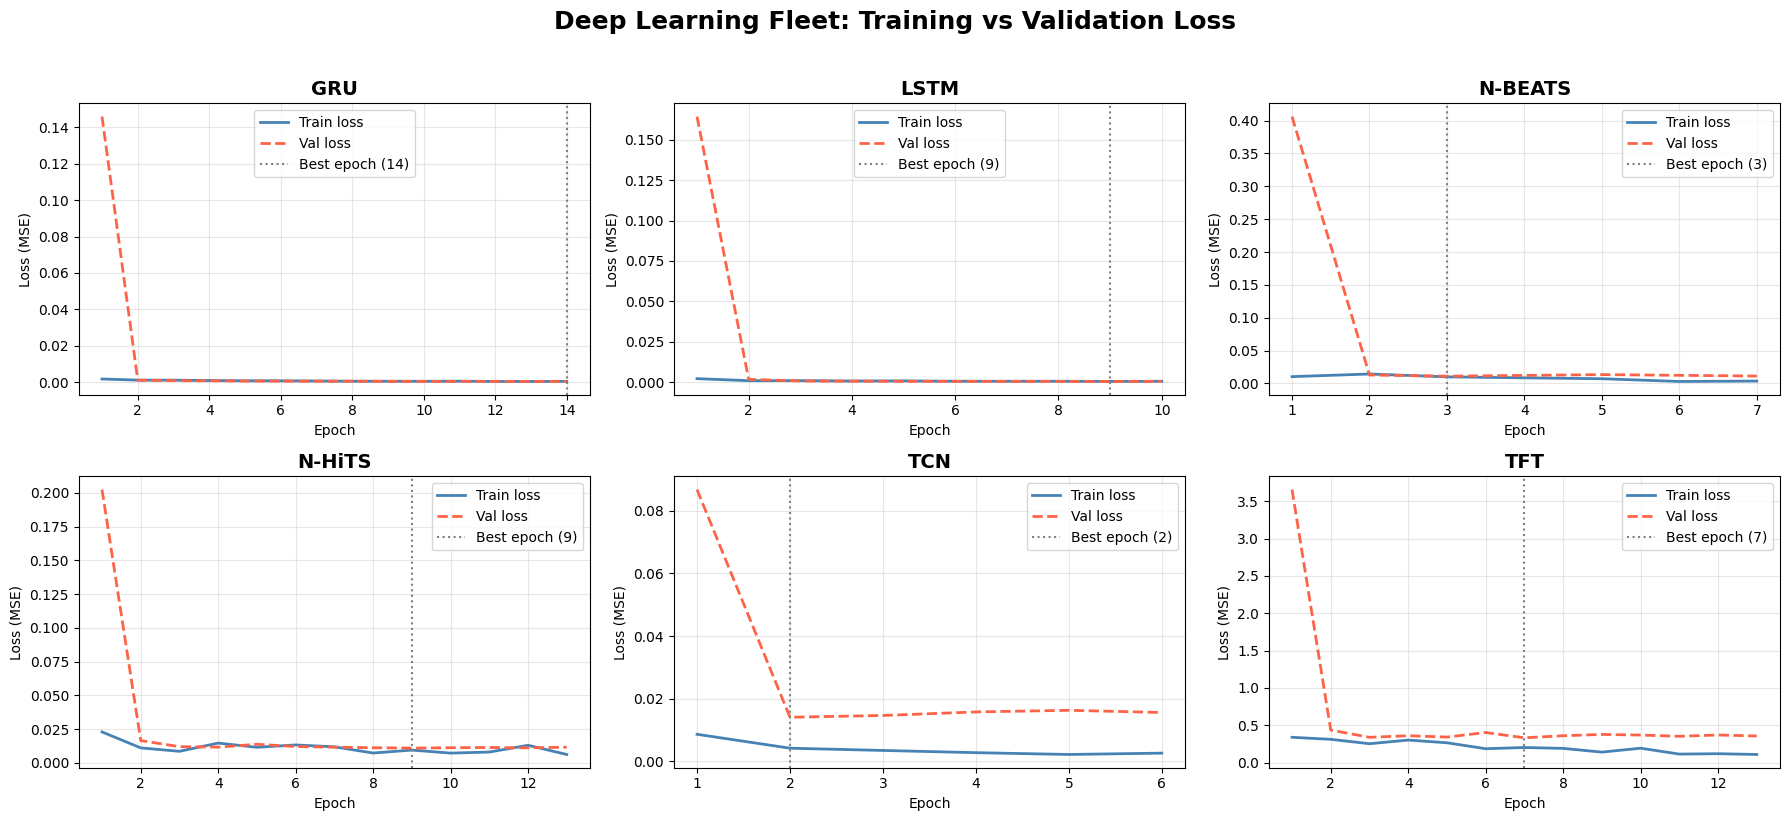

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_saved_loss_curves(save_dir="saved_models"):
    """Reads the saved CSV files and plots the loss curves in a grid."""
    
    # Find all the CSV files in the folder
    csv_files = [f for f in os.listdir(save_dir) if f.endswith('_loss_curves.csv')]
    
    if not csv_files:
        print(f"No loss curve CSVs found in {save_dir}")
        return

    n = len(csv_files)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, file in enumerate(sorted(csv_files)):
        ax = axes[i]
        
        # Get model name from filename (e.g., "LSTM_loss_curves.csv" -> "LSTM")
        model_name = file.replace("_loss_curves.csv", "")
        
        # Load the CSV
        df = pd.read_csv(os.path.join(save_dir, file))
        
        # PyTorch Lightning does a "sanity check" step before Epoch 1, which sometimes 
        # makes val_loss have 1 extra row. We drop NaN rows to cleanly plot them.
        train_data = df[['epoch', 'train_loss']].dropna()
        val_data = df[['epoch', 'val_loss']].dropna()

        # Plot curves
        ax.plot(train_data['epoch'], train_data['train_loss'], label='Train loss', color='steelblue', linewidth=2)
        ax.plot(val_data['epoch'], val_data['val_loss'], label='Val loss', color='tomato', linewidth=2, linestyle='--')

        # Mark the best epoch
        best_epoch = val_data.loc[val_data['val_loss'].idxmin(), 'epoch']
        ax.axvline(best_epoch, color='grey', linestyle=':', linewidth=1.5, label=f'Best epoch ({int(best_epoch)})')

        ax.set_title(model_name, fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (MSE)')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Deep Learning Fleet: Training vs Validation Loss', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Run the function in your notebook!
plot_saved_loss_curves()


🎉 Visualization: Plotting the winning model (TFT) vs Actual Demand...


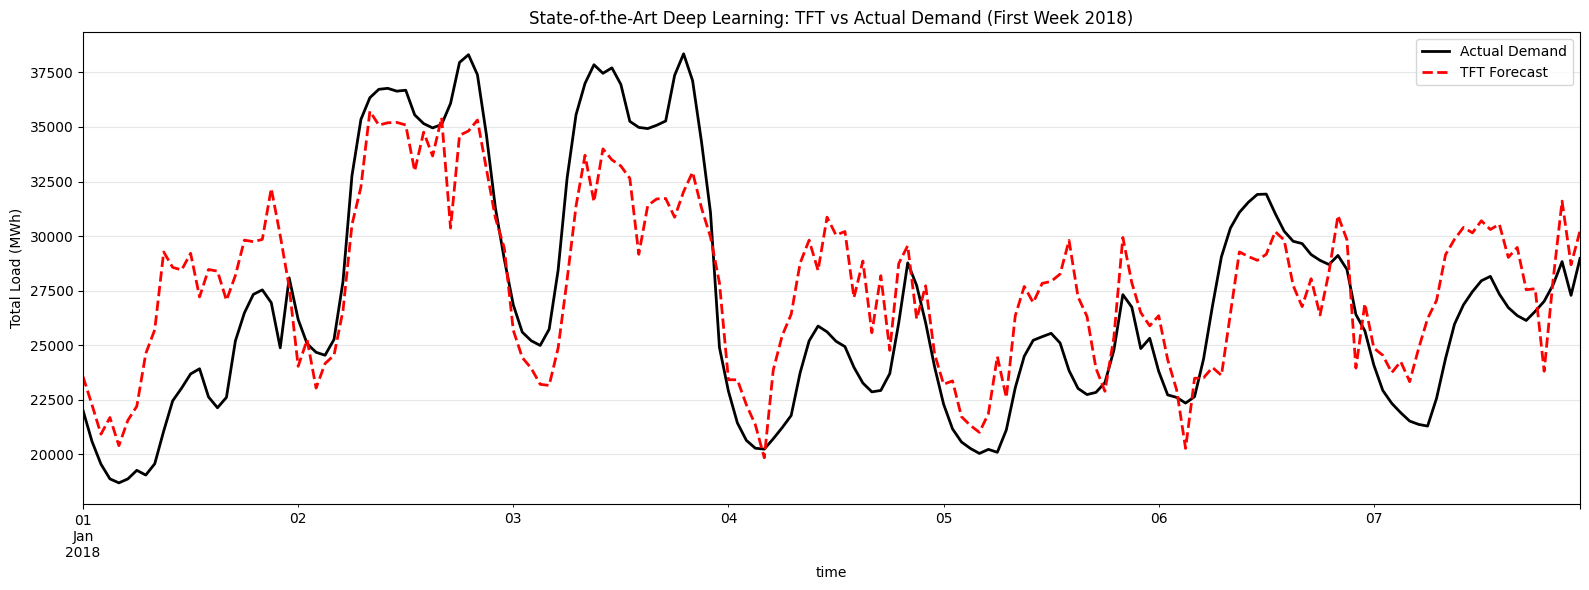

In [6]:
import matplotlib.pyplot as plt

# Step 3: Visualizing the ultimate winner
top_1_name = leaderboard[0][0]
print(f"\n🎉 Visualization: Plotting the winning model ({top_1_name}) vs Actual Demand...")

plt.figure(figsize=(16, 6))
actuals_ts = darts_dataset['test_target_unscaled']

# Plotting the first 168 hours (First week of 2018)
actuals_ts[:168].plot(label='Actual Demand', color='black', linewidth=2)
predictions[top_1_name][:168].plot(label=f'{top_1_name} Forecast', color='red', linestyle='--')
plt.title(f"State-of-the-Art Deep Learning: {top_1_name} vs Actual Demand (First Week 2018)")
plt.ylabel("Total Load (MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

🔍 Running Error Analysis for: TFT

🚨 Finding the Top 3 Worst Predicted Days...


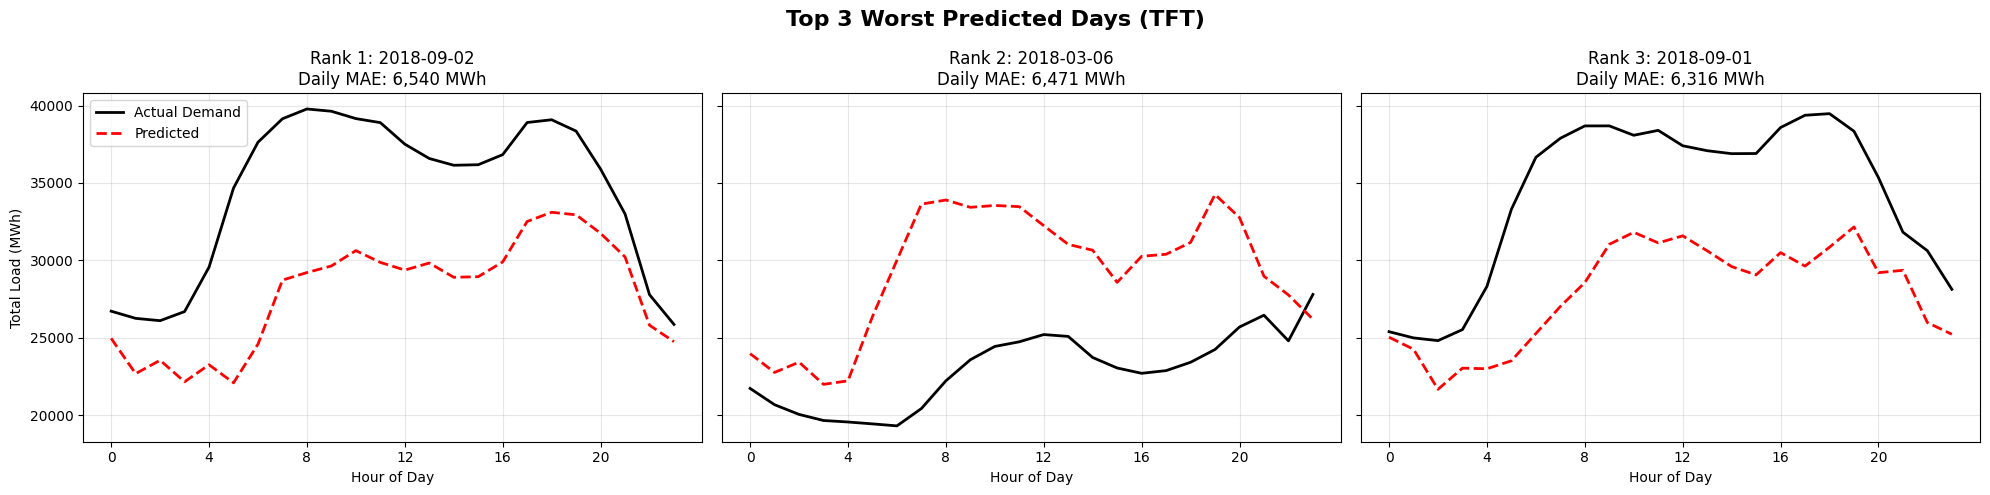


📊 Analyzing Systematic Biases (Hour of Day & Day of Week)...


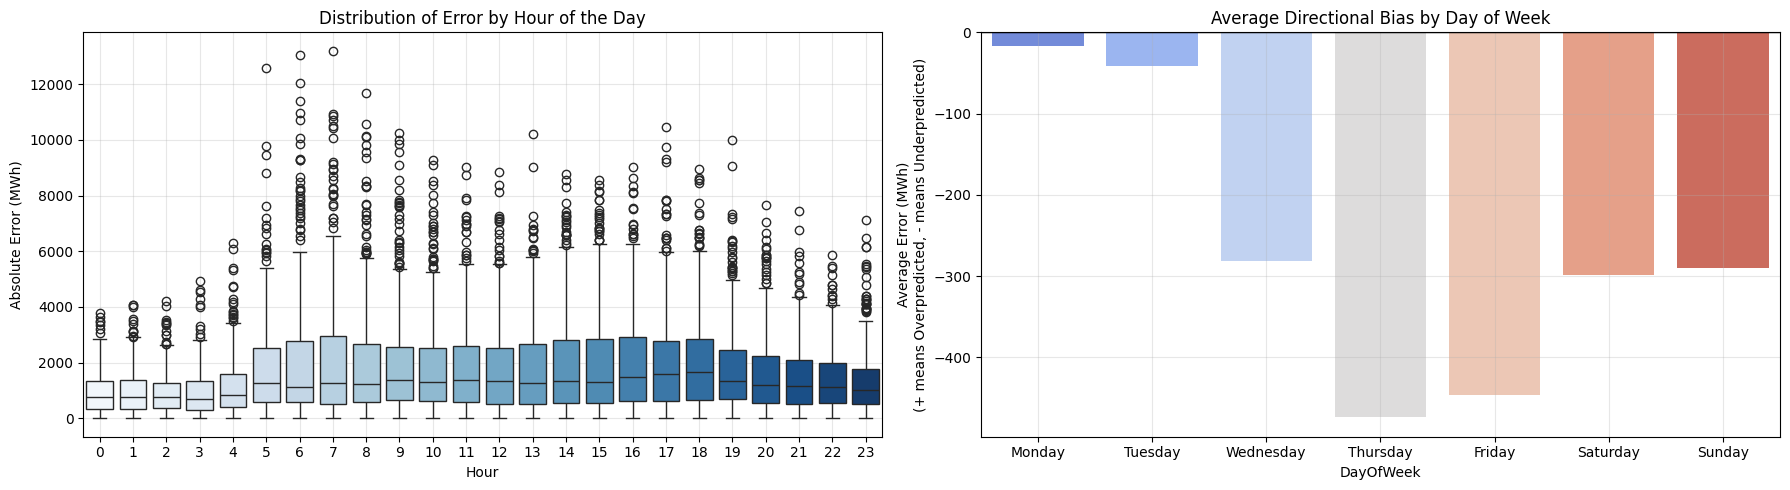


Top 5 Worst Days (Raw Data):
            Daily MAE (MWh)
Date                       
2018-09-02      6539.770598
2018-03-06      6471.183168
2018-09-01      6315.793086
2018-10-13      6088.466219
2018-11-01      5933.804444


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PREPARE THE ERROR DATAFRAME ---
# Get the top model's name (e.g., 'LSTM' or 'GRU')
top_model_name = leaderboard[0][0] 
print(f"🔍 Running Error Analysis for: {top_model_name}")

# Convert Darts TimeSeries back to Pandas DataFrames for easy math
actuals_df = darts_dataset['test_target_unscaled'].to_dataframe()
preds_df = predictions[top_model_name].to_dataframe()

# Merge them together based on the exact time index
error_df = actuals_df.join(preds_df, how='inner', lsuffix='_actual', rsuffix='_pred')
error_df.columns = ['Actual_Demand', 'Predicted_Demand']

# Calculate the error metrics for every single hour
error_df['Error'] = error_df['Predicted_Demand'] - error_df['Actual_Demand'] 
error_df['Absolute_Error'] = np.abs(error_df['Error'])
error_df['Percentage_Error'] = (error_df['Absolute_Error'] / error_df['Actual_Demand']) * 100

# Add temporal columns for grouping
error_df['Date'] = error_df.index.date
error_df['Hour'] = error_df.index.hour
error_df['DayOfWeek'] = error_df.index.day_name()


# --- 2. FIND AND PLOT THE WORST 3 DAYS ---
print("\n🚨 Finding the Top 3 Worst Predicted Days...")
# Group by day and calculate the average Mean Absolute Error for that day
daily_mae = error_df.groupby('Date')['Absolute_Error'].mean().sort_values(ascending=False)
worst_3_days = daily_mae.head(3)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
fig.suptitle(f"Top 3 Worst Predicted Days ({top_model_name})", fontsize=16, fontweight='bold')

for i, (date, mae_val) in enumerate(worst_3_days.items()):
    # Slice the dataframe for just that specific day
    day_data = error_df[error_df['Date'] == date]
    
    axes[i].plot(day_data.index.hour, day_data['Actual_Demand'], label='Actual Demand', color='black', linewidth=2)
    axes[i].plot(day_data.index.hour, day_data['Predicted_Demand'], label='Predicted', color='red', linestyle='dashed', linewidth=2)
    
    axes[i].set_title(f"Rank {i+1}: {date}\nDaily MAE: {mae_val:,.0f} MWh")
    axes[i].set_xlabel("Hour of Day")
    axes[i].set_xticks(range(0, 24, 4))
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel("Total Load (MWh)")
        axes[i].legend()

plt.tight_layout()
plt.show()


# --- 3. SYSTEMATIC ERROR (WHEN DOES IT FAIL?) ---
print("\n📊 Analyzing Systematic Biases (Hour of Day & Day of Week)...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: Error by Hour of Day
sns.boxplot(data=error_df, x='Hour', y='Absolute_Error', ax=ax1, palette='Blues')
ax1.set_title("Distribution of Error by Hour of the Day")
ax1.set_ylabel("Absolute Error (MWh)")
ax1.grid(True, alpha=0.3)

# Plot 2: Average Bias by Day of Week (Are we overpredicting or underpredicting?)
# Using raw Error (not absolute) to see direction. Positive = Overpredicted, Negative = Underpredicted
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=error_df, x='DayOfWeek', y='Error', order=day_order, ax=ax2, palette='coolwarm', errorbar=None)
ax2.set_title("Average Directional Bias by Day of Week")
ax2.set_ylabel("Average Error (MWh)\n(+ means Overpredicted, - means Underpredicted)")
ax2.axhline(0, color='black', linewidth=1) # Zero line
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print out the raw worst days data for the report
print("\nTop 5 Worst Days (Raw Data):")
print(daily_mae.head(5).to_frame(name='Daily MAE (MWh)'))

📊 OVERALL TEST SET ERROR STATISTICS:
----------------------------------------
       Absolute_Error  Percentage_Error
count         8736.00           8736.00
mean          1687.20              5.85
std           1718.19              6.03
min              0.00              0.00
25%            508.22              1.80
50%           1138.46              3.98
75%           2246.06              7.70
max          13201.96             64.61
----------------------------------------

🔍 TOP 10 FEATURES CORRELATED WITH HIGH ERRORS:
load_lag_48                0.161153
is_holiday_madrid          0.149270
load_lag_24                0.138723
is_holiday_barcelona       0.129753
is_holiday                 0.125703
load_lag_168               0.123385
is_holiday_valencia        0.121875
is_holiday_bilbao          0.117095
is_holiday_seville         0.115196
generation wind onshore    0.099891
Name: Absolute_Error, dtype: float64


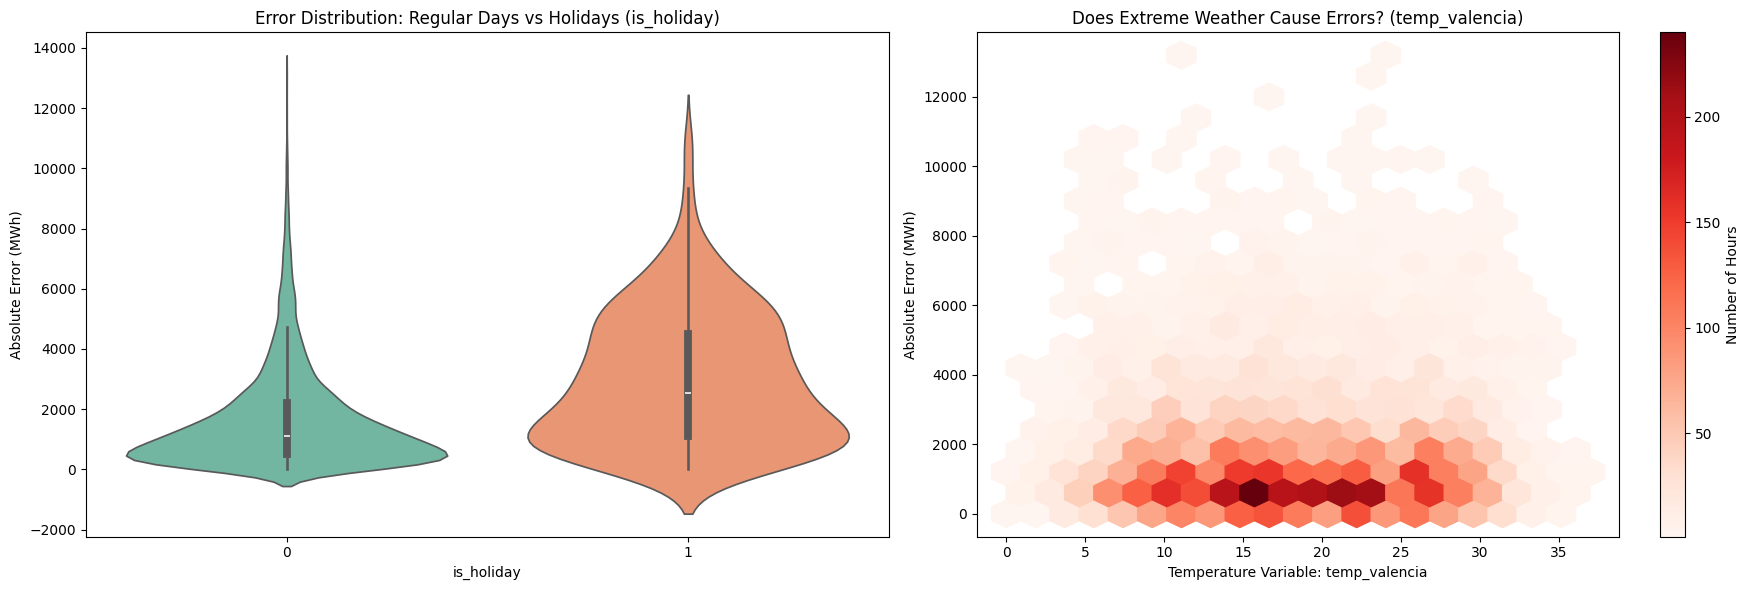

In [8]:
# --- 1. MERGE ERRORS WITH YOUR ORIGINAL FEATURES ---
# Join the error dataframe with your test features (X_test)
# We use an inner join to make sure the timestamps match perfectly
# --- 1. MERGE ERRORS WITH YOUR ORIGINAL FEATURES ---
# Strip the timezone from X_test so it perfectly matches the Darts output
X_test_naive = X_test.copy()
X_test_naive.index = X_test_naive.index.tz_localize(None)

# Now they can safely join!
analysis_df = error_df.join(X_test_naive, how='inner')

# --- 2. OVERALL TEST SET STATISTICS ---
print("📊 OVERALL TEST SET ERROR STATISTICS:")
print("-" * 40)
print(analysis_df[['Absolute_Error', 'Percentage_Error']].describe().round(2))
print("-" * 40)

# --- 3. CORRELATION: WHICH VARIABLES CAUSE THE MOST ERROR? ---
print("\n🔍 TOP 10 FEATURES CORRELATED WITH HIGH ERRORS:")
# Find numeric columns only to avoid correlation errors
numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns
# Calculate correlation with Absolute Error, drop the error columns themselves, and sort
error_correlations = analysis_df[numeric_cols].corr()['Absolute_Error'].drop(
    ['Error', 'Absolute_Error', 'Percentage_Error', 'Actual_Demand', 'Predicted_Demand'], 
    errors='ignore'
).sort_values(ascending=False)

# Print the top 10 features most associated with big mistakes
print(error_correlations.head(10))


# --- 4. VISUALIZING ERROR DRIVERS (HOLIDAYS & WEATHER) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot A: How do Holidays affect the error?
# Let's find your holiday column (assuming it has 'holiday' in the name based on your earlier logs)
holiday_cols = [col for col in analysis_df.columns if 'holiday' in col.lower()]

if holiday_cols:
    main_hol_col = holiday_cols[0] # Grab the first holiday column
    sns.violinplot(data=analysis_df, x=main_hol_col, y='Absolute_Error', ax=ax1, palette='Set2')
    ax1.set_title(f"Error Distribution: Regular Days vs Holidays ({main_hol_col})")
    ax1.set_ylabel("Absolute Error (MWh)")
else:
    ax1.text(0.5, 0.5, "No holiday column found", ha='center')

# Plot B: How does Temperature affect the error?
# Let's find a temperature column (assuming it has 'temp' in the name)
temp_cols = [col for col in analysis_df.columns if 'temp' in col.lower()]

if temp_cols:
    # Let's use the average temperature or the first city's temperature
    main_temp_col = temp_cols[0] 
    
    # A hexbin plot is great for dense scatter data
    hb = ax2.hexbin(analysis_df[main_temp_col], analysis_df['Absolute_Error'], 
                    gridsize=20, cmap='Reds', mincnt=1)
    ax2.set_title(f"Does Extreme Weather Cause Errors? ({main_temp_col})")
    ax2.set_xlabel(f"Temperature Variable: {main_temp_col}")
    ax2.set_ylabel("Absolute Error (MWh)")
    cb = fig.colorbar(hb, ax=ax2)
    cb.set_label('Number of Hours')
else:
    ax2.text(0.5, 0.5, "No temperature column found", ha='center')

plt.tight_layout()
plt.show()

📊 SYSTEMATIC TEMPORAL BIAS ANALYSIS


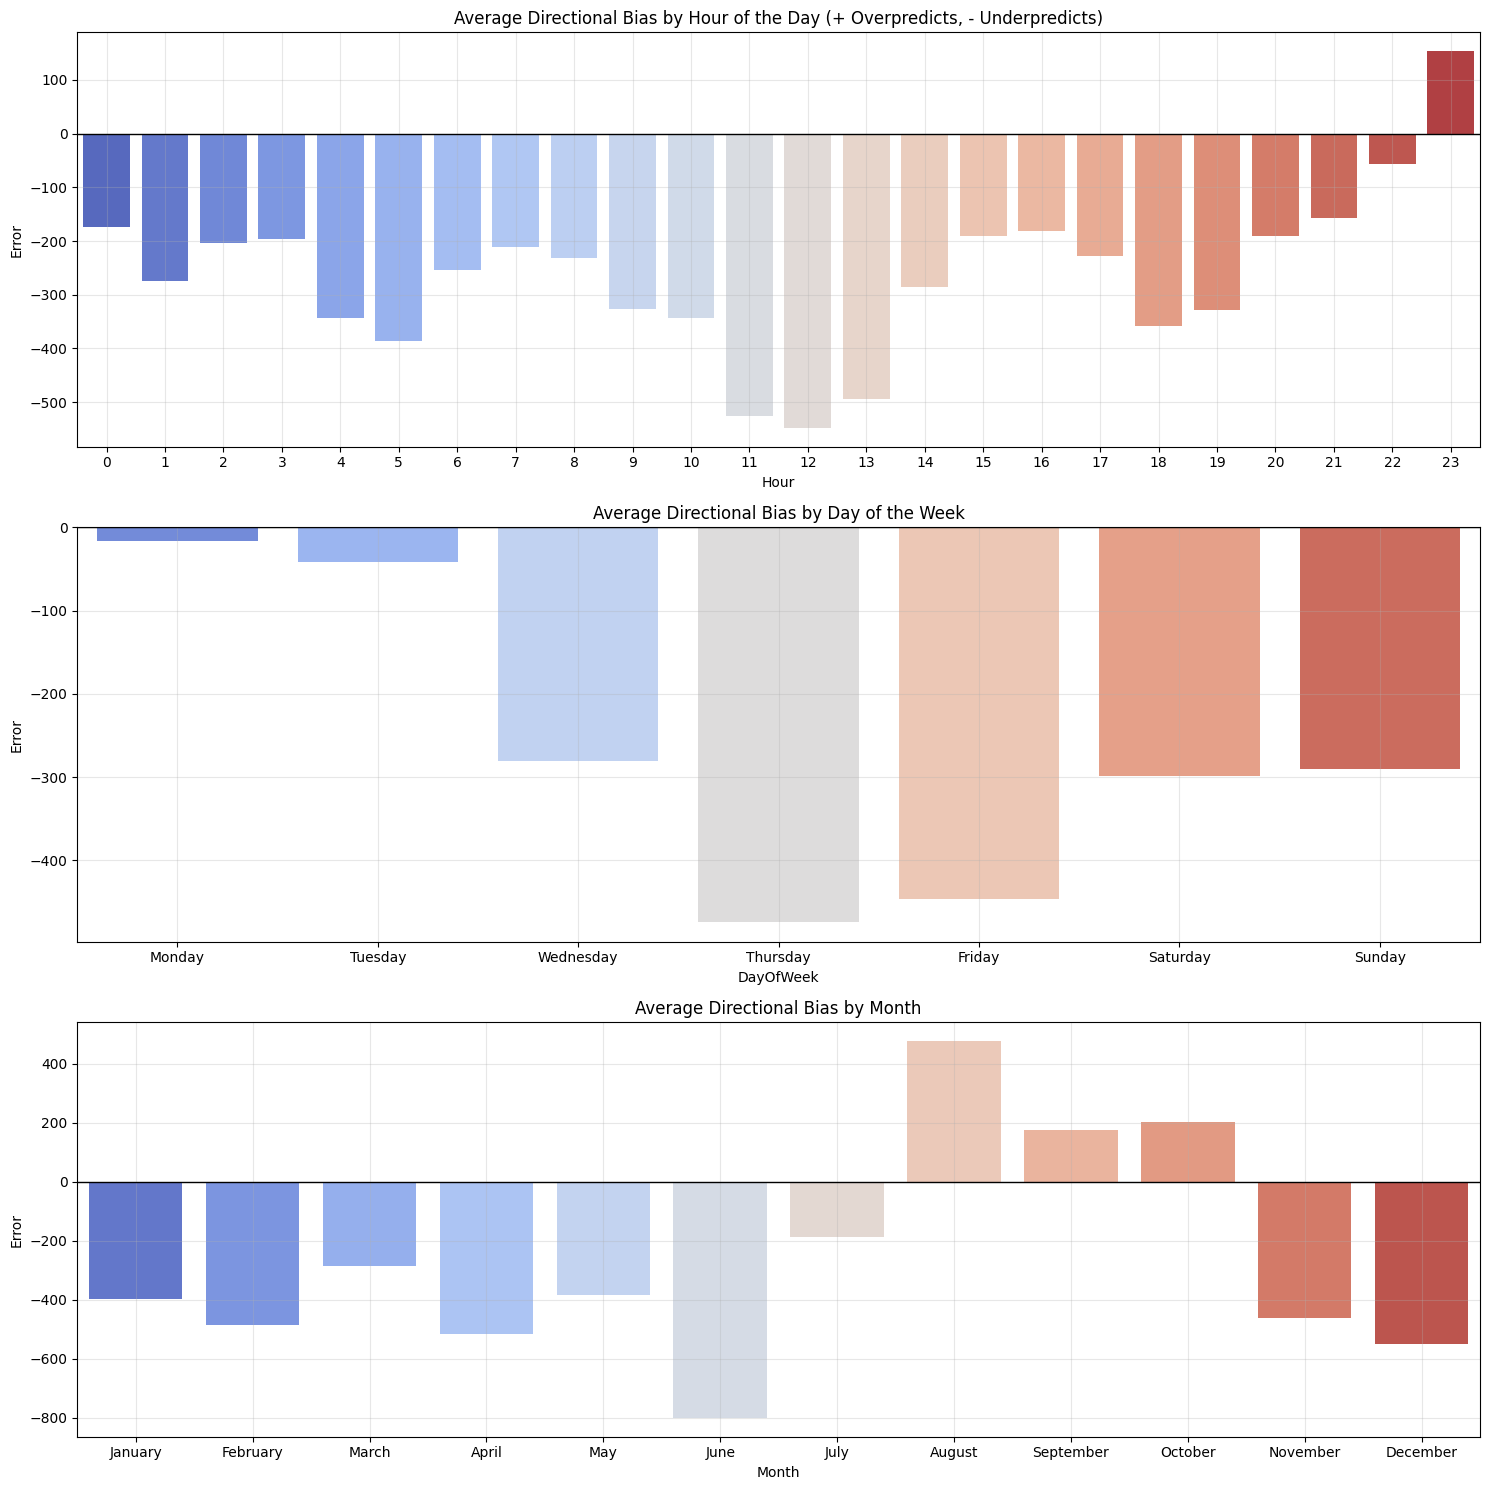


🚨 'BIG ERROR' PROFILER (> 1000 MWh)
--------------------------------------------------
Total Hours in 2018: 8736
Hours with Error > 1000 MWh: 4789 (54.8% of the year)
--------------------------------------------------

🍂 1. Seasonality of Big Errors:
   - Winter: 26.9% of big errors
   - Summer: 25.0% of big errors
   - Autumn: 24.5% of big errors
   - Spring: 23.6% of big errors

🎉 2. Holiday Impact:
   - 3.8% of Big Errors occurred on a holiday.
   - (For context, only 1.4% of normal hours are holidays).

🌡️ 3. Temperature Differences (Average during error):
   - temp_valencia: 18.3° (Big Error Avg) vs 18.2° (Normal Avg) | Volatility (Std): 7.3°
   - temp_min_valencia: 18.3° (Big Error Avg) vs 18.1° (Normal Avg) | Volatility (Std): 7.4°
   - temp_max_valencia: 18.4° (Big Error Avg) vs 18.2° (Normal Avg) | Volatility (Std): 7.3°


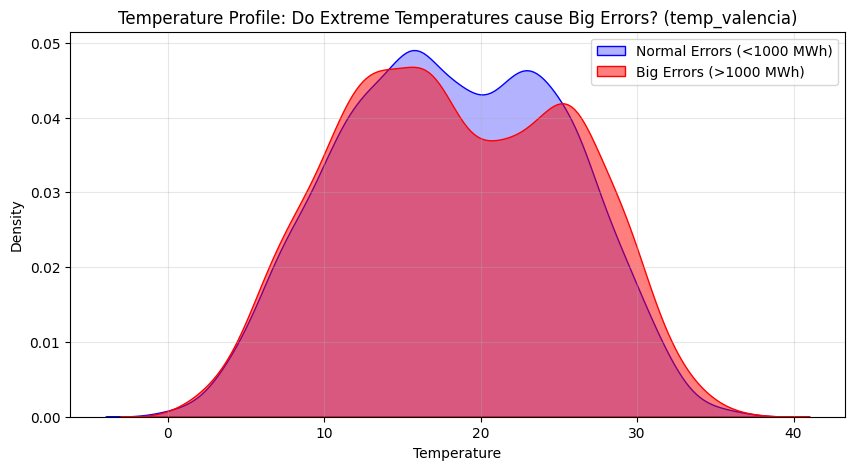

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. MERGE AND PREPARE DATA ---
# Strip the timezone from X_test so it perfectly matches the Darts output
X_test_naive = X_test.copy()
X_test_naive.index = X_test_naive.index.tz_localize(None)

# Merge errors with features
analysis_df = error_df.join(X_test_naive, how='inner')

# Create helpful temporal/calendar columns for analysis
analysis_df['Month'] = analysis_df.index.month_name()
analysis_df['Season'] = analysis_df.index.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# --- 2. TEMPORAL BIAS (HOUR, DAY, MONTH) ---
print("📊 SYSTEMATIC TEMPORAL BIAS ANALYSIS")
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# A. Hour of Day
sns.barplot(data=analysis_df, x='Hour', y='Error', ax=axes[0], palette='coolwarm', errorbar=None)
axes[0].set_title("Average Directional Bias by Hour of the Day (+ Overpredicts, - Underpredicts)")
axes[0].axhline(0, color='black', linewidth=1)
axes[0].grid(True, alpha=0.3)

# B. Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=analysis_df, x='DayOfWeek', y='Error', order=day_order, ax=axes[1], palette='coolwarm', errorbar=None)
axes[1].set_title("Average Directional Bias by Day of the Week")
axes[1].axhline(0, color='black', linewidth=1)
axes[1].grid(True, alpha=0.3)

# C. Month of Year
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.barplot(data=analysis_df, x='Month', y='Error', order=month_order, ax=axes[2], palette='coolwarm', errorbar=None)
axes[2].set_title("Average Directional Bias by Month")
axes[2].axhline(0, color='black', linewidth=1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# --- 3. THE "BIG ERROR" PROFILER (> 1000 MWh) ---
THRESHOLD = 1000
big_errors_df = analysis_df[analysis_df['Absolute_Error'] > THRESHOLD]
normal_errors_df = analysis_df[analysis_df['Absolute_Error'] <= THRESHOLD]

pct_big_errors = (len(big_errors_df) / len(analysis_df)) * 100

print(f"\n🚨 'BIG ERROR' PROFILER (> {THRESHOLD} MWh)")
print("-" * 50)
print(f"Total Hours in 2018: {len(analysis_df)}")
print(f"Hours with Error > {THRESHOLD} MWh: {len(big_errors_df)} ({pct_big_errors:.1f}% of the year)")
print("-" * 50)

# A. What Season do they happen in?
print("\n🍂 1. Seasonality of Big Errors:")
season_counts = big_errors_df['Season'].value_counts(normalize=True) * 100
for season, pct in season_counts.items():
    print(f"   - {season}: {pct:.1f}% of big errors")

# B. Are they happening on holidays?
# (Assuming your holiday column has 'holiday' in the name. We'll find it dynamically)
holiday_cols = [col for col in analysis_df.columns if 'holiday' in col.lower()]
if holiday_cols:
    hol_col = holiday_cols[0]
    hol_big = (big_errors_df[hol_col] > 0).mean() * 100
    hol_normal = (normal_errors_df[hol_col] > 0).mean() * 100
    print("\n🎉 2. Holiday Impact:")
    print(f"   - {hol_big:.1f}% of Big Errors occurred on a holiday.")
    print(f"   - (For context, only {hol_normal:.1f}% of normal hours are holidays).")

# C. What about Extreme Temperatures?
# (Finding temperature columns dynamically)
temp_cols = [col for col in analysis_df.columns if 'temp' in col.lower()]
if temp_cols:
    print("\n🌡️ 3. Temperature Differences (Average during error):")
    for tc in temp_cols[:3]:  # Limit to first 3 cities to keep it readable
        avg_temp_big = big_errors_df[tc].mean()
        avg_temp_normal = normal_errors_df[tc].mean()
        
        # Calculate temperature variance (Standard deviation)
        # High std dev means highly volatile weather during big errors
        std_temp_big = big_errors_df[tc].std()
        
        print(f"   - {tc}: {avg_temp_big:.1f}° (Big Error Avg) vs {avg_temp_normal:.1f}° (Normal Avg) | Volatility (Std): {std_temp_big:.1f}°")

# --- 4. VISUALIZE BIG ERRORS ---
# Let's plot the distribution of temperatures for Normal vs Big Errors
if temp_cols:
    main_temp = temp_cols[0]
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=normal_errors_df, x=main_temp, label=f'Normal Errors (<{THRESHOLD} MWh)', fill=True, color='blue', alpha=0.3)
    sns.kdeplot(data=big_errors_df, x=main_temp, label=f'Big Errors (>{THRESHOLD} MWh)', fill=True, color='red', alpha=0.5)
    plt.title(f"Temperature Profile: Do Extreme Temperatures cause Big Errors? ({main_temp})")
    plt.xlabel("Temperature")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()